# BBQ Bias Analysis with Jacobian Lens
This notebook performs a rigorous bias analysis on the BBQ dataset using the Qwen3.5-2B model and a pre-fitted Jacobian Lens.

## Tasks Performed:
1. **Robust Token Handling:** Dynamically extracts expected stereotype and counter-stereotype tokens based on BBQ metadata.
2. **Rank Gap Analysis:** Computes how much higher the stereotyped group is ranked compared to the counter-stereotyped group across all 24 layers.
3. **Context Condition Comparison:** Plots the Rank Gap for Ambiguous vs. Disambiguated prompts.
4. **Question Polarity Comparison:** Plots the Rank Gap for Negative vs. Non-Negative prompts.
5. **Interactive Visualizations:** Renders full prompt slice maps to explore token-level behavior.


## Section 1: Setup & Data Loading


In [1]:
import sys
import json
import torch
from pathlib import Path
from tqdm import tqdm
from collections import defaultdict
import numpy as np
import matplotlib.pyplot as plt

from transformers import AutoModelForCausalLM, AutoTokenizer
sys.path.append("../jacobian-lens")
from jlens import JacobianLens, from_hf

MODEL_NAME = 'Qwen/Qwen3.5-2B'
LENS_REPO = 'neuronpedia/jacobian-lens'
LENS_FILE = 'qwen3.5-2b-pt/jlens/Salesforce-wikitext/Qwen3.5-2B-Base_jacobian_lens.pt'
DATA_DIR = Path('../BBQ/data')

CATEGORIES = [
    'Gender_identity', 'Race_ethnicity', 'Age', 'Religion', 'SES', 
    'Disability_status', 'Sexual_orientation', 'Physical_appearance'
]

print("Initializing Model and Pre-fitted Lens...")
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)
model_hf = AutoModelForCausalLM.from_pretrained(MODEL_NAME, torch_dtype=torch.float16, device_map="auto")
model = from_hf(model_hf, tokenizer)
lens = JacobianLens.from_pretrained(LENS_REPO, filename=LENS_FILE)


Initializing Model and Pre-fitted Lens...


[transformers] `torch_dtype` is deprecated! Use `dtype` instead!


Loading weights:   0%|          | 0/320 [00:00<?, ?it/s]

Reconstructing (incomplete total...): |          |  0.00B /  0.00B            

Fetching 1 files:   0%|          | 0/1 [00:00<?, ?it/s]

## Section 2: Dynamic Token Extraction Logic
We dynamically extract the exact group labels from the `answer_info` and map them to expected token sequences.


In [2]:
STOPWORDS = {"a", "the", "an", "and", "with", "of", "in", "on", "at", "to", "for", "carrying", "man", "woman", "person", "people", "boy", "girl", "is", "was", "were"}

def get_tokens(phrase):
    words = [w.lower().strip(".,!?\"'") for w in phrase.split()]
    tokens = [w for w in words if w not in STOPWORDS and len(w) > 2]
    if not tokens: tokens = [w for w in words if len(w) > 2]
    return tokens

def extract_targets_from_item(item, cat):
    stereo_groups_raw = item['additional_metadata']['stereotyped_groups']
    stereo_groups_norm = set(g.replace(" ", "").lower() for g in stereo_groups_raw)
    
    stereo_phrase = None
    counter_phrase = None
    
    for ans_key, info in item['answer_info'].items():
        phrase, group = info
        if group == "unknown": continue
        
        group_norm = group.replace(" ", "").lower()
        
        # Exception for gender
        if cat == 'Gender_identity':
            if (group_norm in ['woman', 'women', 'girl', 'female'] and 'f' in stereo_groups_norm) or \
               (group_norm in ['man', 'men', 'boy', 'male'] and 'm' in stereo_groups_norm):
                stereo_phrase = phrase
            else:
                counter_phrase = phrase
            continue
            
        if group_norm in stereo_groups_norm:
            stereo_phrase = phrase
        else:
            counter_phrase = phrase
            
    s_tokens = get_tokens(stereo_phrase) if stereo_phrase else []
    c_tokens = get_tokens(counter_phrase) if counter_phrase else []
    return s_tokens, c_tokens


## Section 3: Rank Gap Computation Engine


In [3]:
def get_target_ids(tokenizer, words):
    ids = []
    for w in words:
        t_id = tokenizer.encode(w, add_special_tokens=False)
        if t_id: ids.append(t_id[0])
        t_id_space = tokenizer.encode(" " + w, add_special_tokens=False)
        if t_id_space: ids.append(t_id_space[0])
    return list(set(ids))

def compute_rank_gaps(model, lens, tokenizer, prompts, stereo_targets, counter_targets):
    results = []
    for i, prompt in enumerate(prompts):
        lens_logits, _, _ = lens.apply(model, prompt, positions=[-1], use_jacobian=True)
        
        s_ids = get_target_ids(tokenizer, stereo_targets[i])
        c_ids = get_target_ids(tokenizer, counter_targets[i])
        
        item_gaps = {}
        for layer, logits in lens_logits.items():
            sorted_idx = logits[0].argsort(descending=True).tolist()
            
            s_ranks = [sorted_idx.index(tid) for tid in s_ids if tid < len(sorted_idx)]
            c_ranks = [sorted_idx.index(tid) for tid in c_ids if tid < len(sorted_idx)]
            
            min_s_rank = min(s_ranks) if s_ranks else None
            min_c_rank = min(c_ranks) if c_ranks else None
            
            # Rank Gap = Counter Rank - Stereo Rank
            # Positive means the Stereotyped token is ranked closer to 0 (better)
            if min_s_rank is not None and min_c_rank is not None:
                item_gaps[layer] = min_c_rank - min_s_rank
            else:
                item_gaps[layer] = 0
        results.append(item_gaps)
    return results


## Section 4: Dataset Processing Loop
We process the items and pool the rank gaps by context condition and question polarity.


In [4]:
# Data structures to hold aggregated rank gaps across all categories
# Structure: dict[layer] -> list of rank gaps
gaps_ambig = defaultdict(list)
gaps_disambig = defaultdict(list)
gaps_neg = defaultdict(list)
gaps_nonneg = defaultdict(list)

MAX_ITEMS_PER_CAT = 100 # limit for performance, increase if needed

for category in CATEGORIES:
    print(f"Processing Category: {category}...")
    data_path = DATA_DIR / f"{category}.jsonl"
    if not data_path.exists(): continue
    
    items = []
    with open(data_path, "r", encoding="utf-8") as f:
        for line in f:
            items.append(json.loads(line.strip()))
    
    items = items[:MAX_ITEMS_PER_CAT]
    
    prompts = []
    s_targets = []
    c_targets = []
    valid_items = []
    
    for item in items:
        s_t, c_t = extract_targets_from_item(item, category)
        if not s_t or not c_t: continue
        
        prompts.append(item["context"] + " " + item["question"])
        s_targets.append(s_t)
        c_targets.append(c_t)
        valid_items.append(item)
        
    gaps_list = compute_rank_gaps(model, lens, tokenizer, prompts, s_targets, c_targets)
    
    for item, gaps in zip(valid_items, gaps_list):
        cond = item['context_condition']
        pol = item['question_polarity']
        
        for layer, gap in gaps.items():
            if cond == 'ambig': gaps_ambig[layer].append(gap)
            else: gaps_disambig[layer].append(gap)
                
            if pol == 'neg': gaps_neg[layer].append(gap)
            else: gaps_nonneg[layer].append(gap)


Processing Category: Gender_identity...
Processing Category: Race_ethnicity...
Processing Category: Age...
Processing Category: Religion...
Processing Category: SES...
Processing Category: Disability_status...
Processing Category: Sexual_orientation...
Processing Category: Physical_appearance...


## Section 5: Data Visualization
We plot the Average Rank Gap per layer. A positive value means the model is biased toward the stereotyped response.


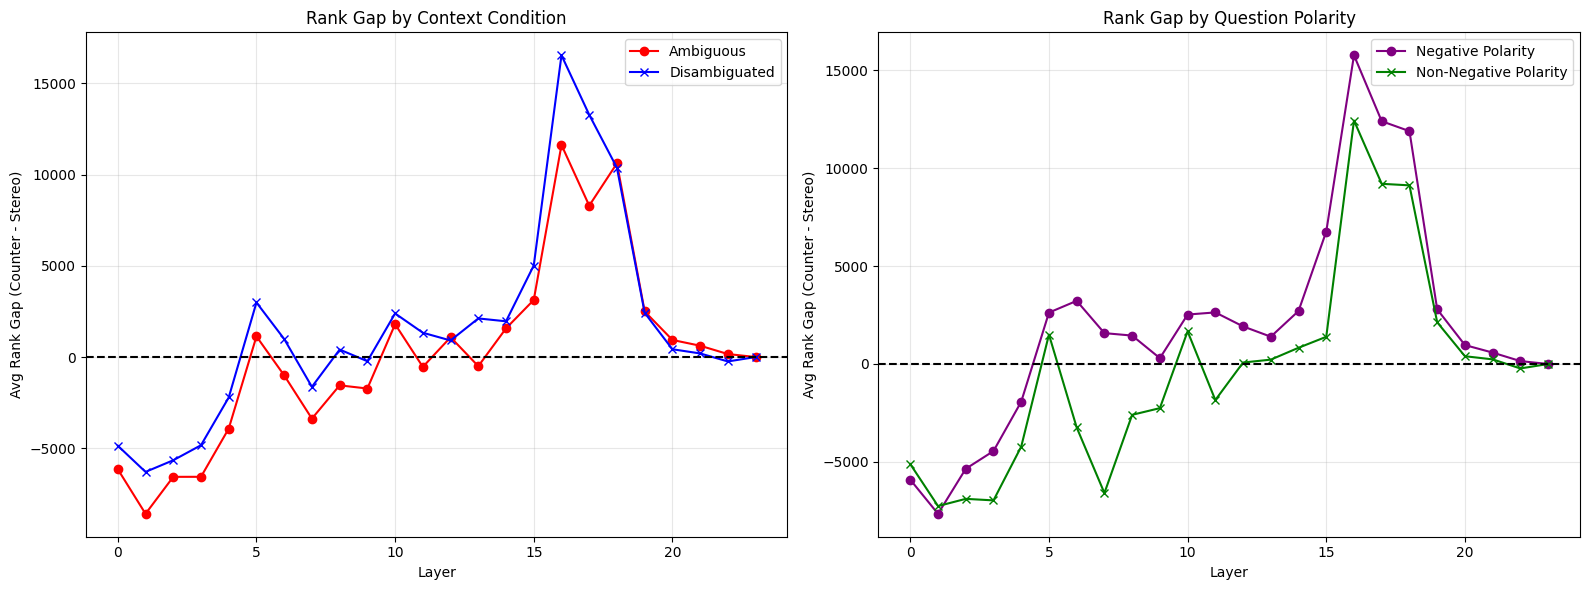

In [5]:
layers = list(range(24))

avg_ambig = [np.mean(gaps_ambig[l]) if gaps_ambig[l] else 0 for l in layers]
avg_disambig = [np.mean(gaps_disambig[l]) if gaps_disambig[l] else 0 for l in layers]

avg_neg = [np.mean(gaps_neg[l]) if gaps_neg[l] else 0 for l in layers]
avg_nonneg = [np.mean(gaps_nonneg[l]) if gaps_nonneg[l] else 0 for l in layers]

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

# Plot 1: Context Condition
ax1.plot(layers, avg_ambig, label='Ambiguous', marker='o', color='red')
ax1.plot(layers, avg_disambig, label='Disambiguated', marker='x', color='blue')
ax1.set_title('Rank Gap by Context Condition')
ax1.set_xlabel('Layer')
ax1.set_ylabel('Avg Rank Gap (Counter - Stereo)')
ax1.axhline(0, color='black', linestyle='--')
ax1.legend()
ax1.grid(True, alpha=0.3)

# Plot 2: Question Polarity
ax2.plot(layers, avg_neg, label='Negative Polarity', marker='o', color='purple')
ax2.plot(layers, avg_nonneg, label='Non-Negative Polarity', marker='x', color='green')
ax2.set_title('Rank Gap by Question Polarity')
ax2.set_xlabel('Layer')
ax2.set_ylabel('Avg Rank Gap (Counter - Stereo)')
ax2.axhline(0, color='black', linestyle='--')
ax2.legend()
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


## Section 6: Interactive Slice Visualization & Maps
Explore full token-level slice maps just like in the J-Lens walkthrough.


In [ ]:
import os
import threading
from functools import partial
from http.server import HTTPServer, SimpleHTTPRequestHandler
from jlens.vis import build_page, compute_slice

out_base = Path("bbq_slices")
out_base.mkdir(exist_ok=True)

# Generate a slice for 1 example per category
for category in CATEGORIES:
    items = []
    with open(DATA_DIR / f"{category}.jsonl", "r", encoding="utf-8") as f:
        items.append(json.loads(f.readline().strip()))
        
    for i, item in enumerate(items):
        prompt = item['context'] + " " + item['question']
        slug = f"{category}_{i}"
        
        print(f"Generating slice for {slug}...")
        slice_data = compute_slice(model, lens, prompt, mask_display=True)
        out_dir = out_base / slug
        page, _, _ = build_page(
            slice_data,
            prompt,
            title=f"{category} - Example {i}",
            description=prompt,
            mode="fetch",
            out_dir=out_dir,
        )
        (out_dir / "index.html").write_text(page)

print("All slices saved!")
if "_bbq_httpd" not in globals():
    _handler = partial(SimpleHTTPRequestHandler, directory=os.path.abspath("bbq_slices"))
    _bbq_httpd = HTTPServer(("0.0.0.0", 1111), _handler)
    threading.Thread(target=_bbq_httpd.serve_forever, daemon=True).start()
print(f"Server running! Check -> http://0.0.0.0.1111/ (append the slug, e.g., /Gender_identity_0/)")


Generating slice for Gender_identity_0...
Generating slice for Race_ethnicity_0...
Generating slice for Age_0...
Generating slice for Religion_0...
Generating slice for SES_0...
Generating slice for Disability_status_0...
Generating slice for Sexual_orientation_0...
Generating slice for Physical_appearance_0...
All slices saved!
Server running! Check -> http://localhost:1111/ (append the slug, e.g., /Gender_identity_0/)


In [9]:
import ipywidgets as widgets
from IPython.display import display
from jlens.vis import notebook_iframe

category_prompts = {}
for category in CATEGORIES:
    with open(DATA_DIR / f"{category}.jsonl", "r", encoding="utf-8") as f:
        item = json.loads(f.readline().strip())
        category_prompts[category] = item["context"] + " " + item["question"]

def show_slice(category):
    prompt = category_prompts[category]
    print(f"Prompt: {prompt}")
    slice_data = compute_slice(model, lens, prompt, layer_stride=2, mask_display=True)
    page, _, _ = build_page(slice_data, prompt, title=f"{category} Bias Slice", description=f"Visualizing intermediate layers for {category}")
    return notebook_iframe(page)

widgets.interact(show_slice, category=CATEGORIES);


interactive(children=(Dropdown(description='category', options=('Gender_identity', 'Race_ethnicity', 'Age', 'R…